# Semantic count comparisons (per generation)

Compares raw semantic-tag counts (`objects`, `stuff`, `spatial_relations`, `attr_color`)
across the three task conditions (perception / immediate memory / delayed memory) **within one
generation group**.

Set `GENERATION` in the config cell below to `"aigen"` or `"nogen"` (or `"plain"`), then run the
whole notebook. Figures are saved under that generation's own `graphs/nlp_graphs` folder and
filenames are prefixed with the generation, so aigen and nogen outputs never collide.

Source: `<processed_dir>/nlp_analysis/trials_final_semantic_tags.csv` for each condition in the
selected generation. Conditions whose file is missing are skipped automatically.

**Raw counts only** — these are not yet validated against the image, and the GPT baseline is not
included yet. Each tag column is a stringified list; the count is its length.

Palette matches `within_gen_similarity_plotting.ipynb` (Dark2 green/orange/purple per condition)
so every figure lines up.

In [11]:
import sys
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Find project root (the dir containing config.py) regardless of where the notebook sits.
project_root = Path.cwd()
while not (project_root / "config.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config
print("project root:", project_root)

# --- Which generation group to analyse ---------------------------------------
# Change this to "aigen", "nogen", or "plain" and re-run the whole notebook.
GENERATION = "nogen"
assert GENERATION in config.GROUPS_BY_GEN, f"unknown generation {GENERATION!r}"
print("generation:", GENERATION)

# --- Style + fixed color maps (reused in every figure for alignment) ---
sns.set_theme(style="whitegrid")
TASK_ORDER  = ["perception", "immediate", "delay"]
TASK_COLORS = {"perception": "#1b9e77", "immediate": "#d95f02", "delay": "#7570b3"}  # Dark2
TASK_LABELS = {"perception": "Perception", "immediate": "Immediate\nmemory", "delay": "Delayed\nmemory"}

# Semantic-tag categories: csv column -> nice axis label.
CATEGORIES = {
    "objects": "Objects",
    "stuff": "Stuff",
    "spatial_relations": "Spatial relations",
    "attr_color": "Color attributes",
    "scene_category": "Scene category",
    "adjectives": "Adjectives",
}

# Output location: each generation gets its own nlp_graphs subfolder so outputs never collide.
GRAPHS = config.ROOT / "analysis" / "outputs" / config.DATASET / GENERATION / "graphs" / "nlp_graphs"
GRAPHS.mkdir(parents=True, exist_ok=True)
print("saving figures to:", GRAPHS)

project root: /mnt/hdd/anatkorol/Imagination_in_translation
generation: nogen
saving figures to: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/nogen/graphs/nlp_graphs


In [12]:
# --- Load the selected generation's semantic-tag tables into one tidy frame, tagged with task ---
# The semantic-tag CSV lives in a nlp_analysis subfolder of each condition's processed_dir
# and is NOT a config.FILENAMES canonical table, so we resolve it by hand here.
CONDITIONS = config.GROUPS_BY_GEN[GENERATION]   # e.g. ['nogen_perc', 'nogen_imm', 'nogen_del']
SEM_FILE = "trials_final_semantic_tags.csv"


def _count(cell):
    """Length of a stringified list cell; 0 for empty / NaN / unparseable."""
    if pd.isna(cell):
        return 0
    try:
        val = ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        return 0
    return len(val) if isinstance(val, (list, tuple)) else 0


frames = []
for c in CONDITIONS:
    p = config.paths_for(c).processed_dir / "nlp_analysis" / SEM_FILE
    if not p.exists():
        print(f"skip {c}: {SEM_FILE} not found ({p})")
        continue
    d = pd.read_csv(p)
    cm = config.mapping_data["CONDITIONS"][c]
    d["condition"], d["generation"], d["task"] = c, cm["generation"], cm["task"]
    for col in CATEGORIES:
        d[f"n_{col}"] = d[col].apply(_count)
    frames.append(d)
    print(f"loaded {c}: {len(d)} rows, {d['uid'].nunique()} participants")

df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
df["attempt"] = df["attempt"].astype(int)
df["task"].value_counts()

loaded nogen_perc: 327 rows, 23 participants
loaded nogen_imm: 309 rows, 22 participants
loaded nogen_del: 213 rows, 17 participants


task
perception    327
immediate     309
delay         213
Name: count, dtype: int64

## Aggregation

Per-participant mean count at the `(task, uid, attempt)` level (collapsing across sessions and
ground-truth images) gives one point per participant per attempt. Within each condition the three
attempts are drawn as grouped bars (learning curve); each bar is the mean across participants with
an SE error bar, and the per-participant points are overlaid on top.

In [13]:
# Attempt palette (viridis): used identically in all four figures so they stay comparable.
ATTEMPT_COLORS = {1: "#440154", 2: "#21918c", 3: "#fde725"}


def per_participant(category):
    """One row per (task, uid, attempt): mean count for `category` across that participant's
    sessions / ground-truth images for that attempt."""
    col = f"n_{category}"
    return (df.groupby(["task", "uid", "attempt"], as_index=False)[col]
              .mean()
              .rename(columns={col: "count"}))


def plot_count(category, save=True):
    """Grouped bars per attempt within each condition: bar = mean across participants (SE error
    bar), with per-participant points overlaid."""
    label = CATEGORIES[category]
    pp = per_participant(category)
    present = [t for t in TASK_ORDER if t in pp["task"].unique()]
    attempts = sorted(pp["attempt"].unique())

    width = 0.8 / len(attempts)
    x = np.arange(len(present))
    fig, ax = plt.subplots(figsize=(4 + 3 * len(present), 8))

    for i, attempt in enumerate(attempts):
        pos = x + (i - (len(attempts) - 1) / 2) * width
        means, ses = [], []
        for t in present:
            vals = pp[(pp["task"] == t) & (pp["attempt"] == attempt)]["count"]
            means.append(vals.mean())
            ses.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0)
        ax.bar(pos, means, width, yerr=ses, color=ATTEMPT_COLORS[attempt],
               edgecolor="black", linewidth=1.2, capsize=4,
               error_kw={"elinewidth": 1.5, "ecolor": "black"}, zorder=2)

        # Per-participant points over each bar.
        for j, t in enumerate(present):
            dots = pp[(pp["task"] == t) & (pp["attempt"] == attempt)]["count"]
            jitter = np.random.uniform(-width * 0.18, width * 0.18, size=len(dots))
            ax.scatter(pos[j] + jitter, dots, color="black", alpha=0.45, s=22, zorder=3)

    ax.set_title(f"{GENERATION} — {label}: count across attempts by condition", fontsize=24, pad=18)
    ax.set_ylabel(f"Mean {label.lower()} count (per participant)", fontsize=18, labelpad=12)
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels([TASK_LABELS[t] for t in present], fontsize=18, linespacing=0.9)
    ax.tick_params(axis="y", labelsize=14)
    # Y ticks in steps of 2 so every figure lines up with the aigen count graphs.
    ax.yaxis.set_major_locator(plt.MultipleLocator(2))

    legend_elements = [
        Line2D([0], [0], marker="s", linestyle="None", markersize=13,
               markerfacecolor=ATTEMPT_COLORS[a], markeredgecolor="black",
               label=f"Attempt {a}")
        for a in attempts
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=15, frameon=True, borderpad=1)

    sns.despine()
    fig.tight_layout()
    if save:
        out = GRAPHS / f"{GENERATION}_{category}_count_by_condition.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        print("saved:", out)
    plt.show()
    return pp

## 1. Objects

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/nogen/graphs/nlp_graphs/nogen_objects_count_by_condition.png


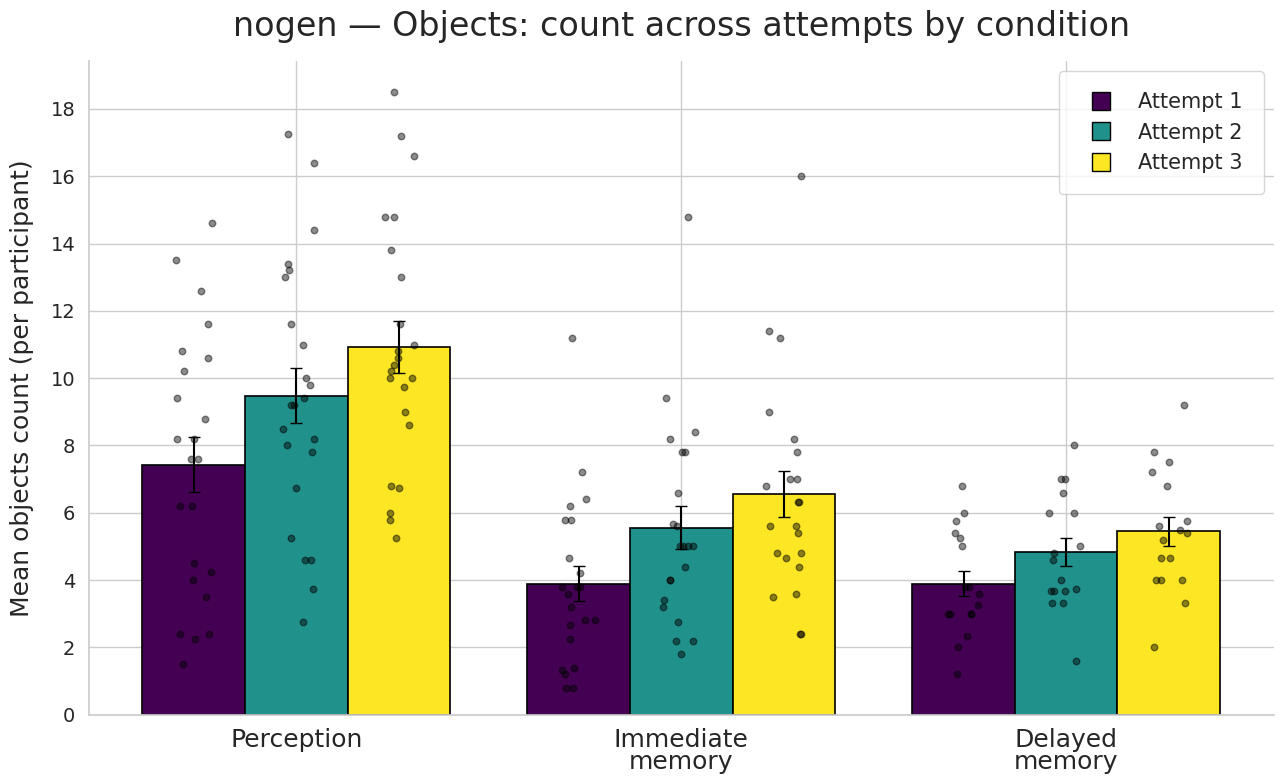

In [14]:
objects_pp = plot_count("objects")

## 2. Stuff (mass nouns)

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/nogen/graphs/nlp_graphs/nogen_stuff_count_by_condition.png


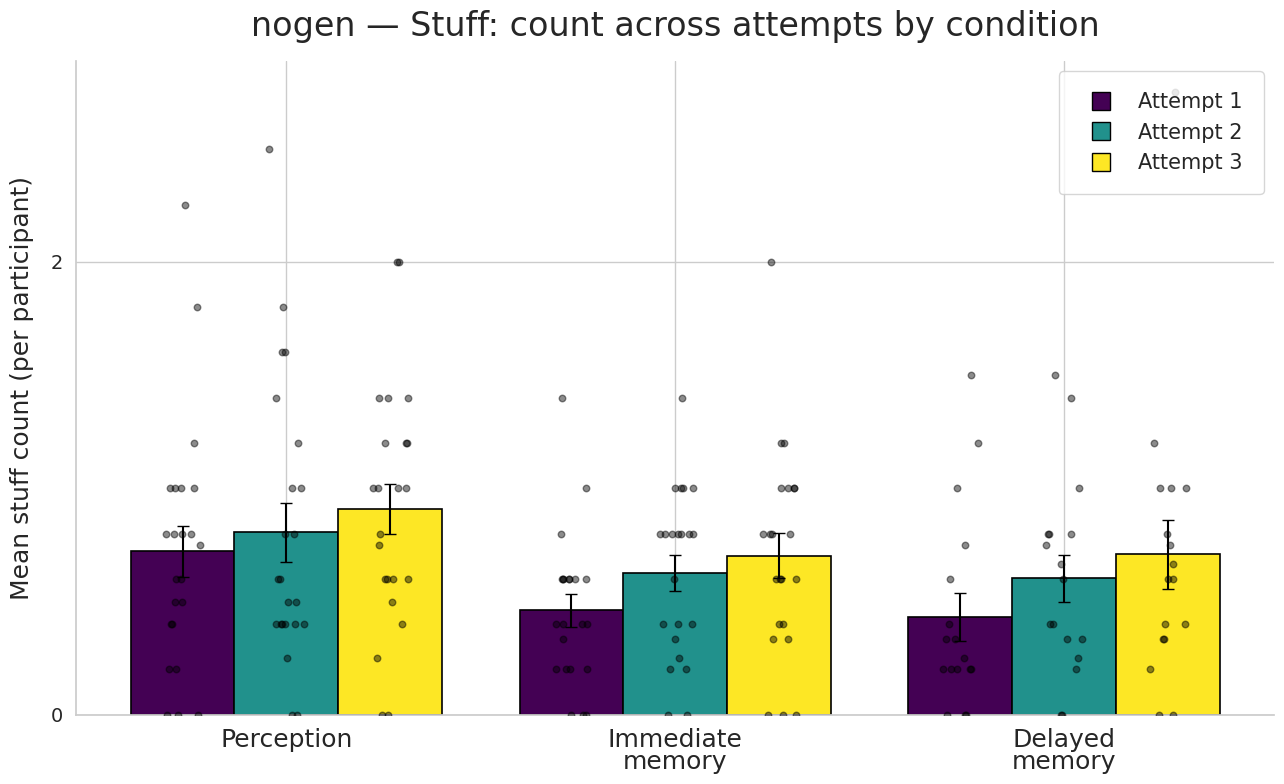

In [15]:
stuff_pp = plot_count("stuff")

## 3. Spatial relations

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/nogen/graphs/nlp_graphs/nogen_spatial_relations_count_by_condition.png


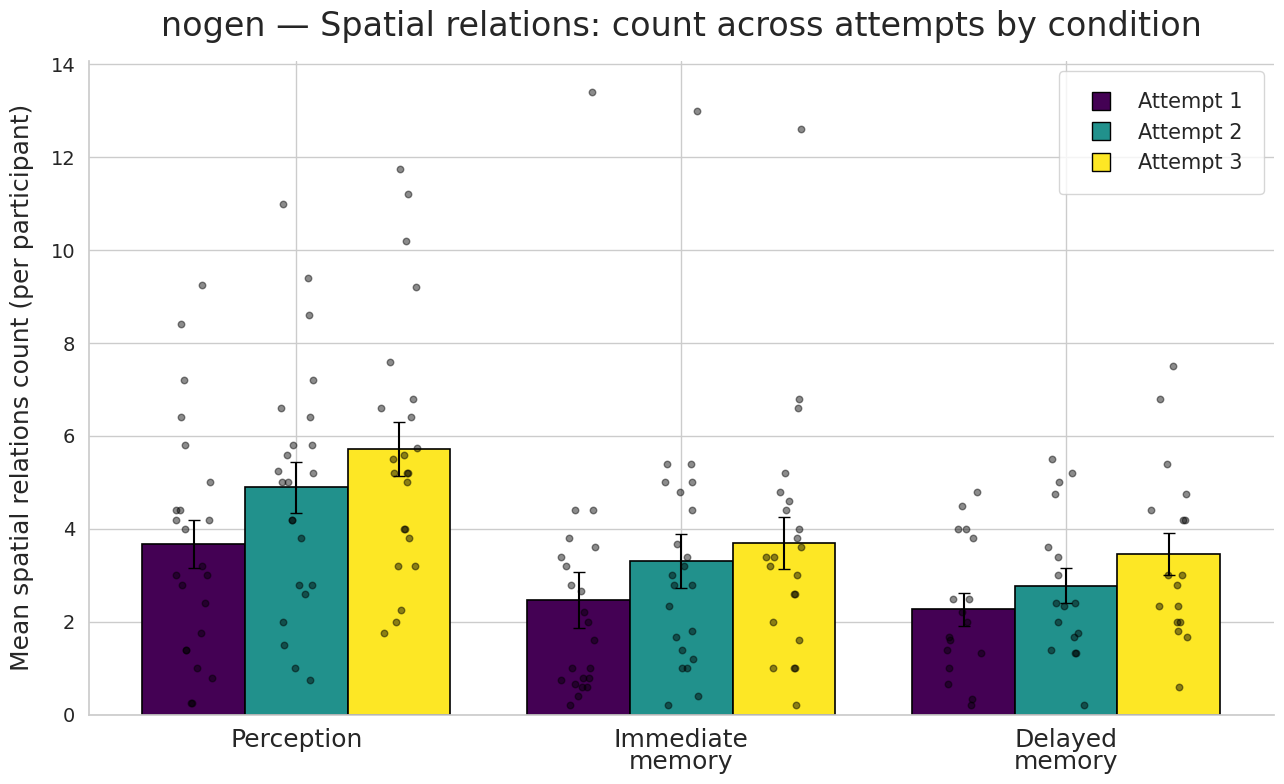

In [16]:
spatial_pp = plot_count("spatial_relations")

## 4. Color attributes

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/nogen/graphs/nlp_graphs/nogen_attr_color_count_by_condition.png


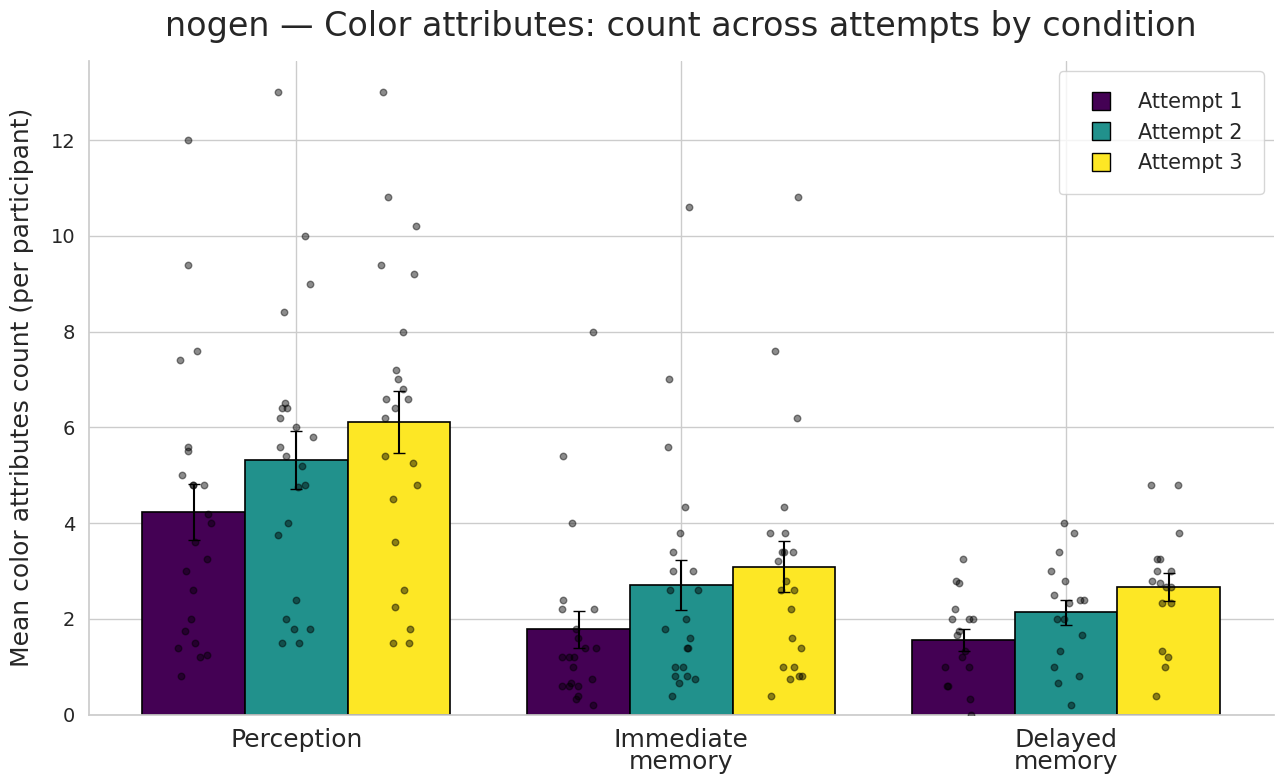

In [17]:
color_pp = plot_count("attr_color")

## 5. Scene category

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/nogen/graphs/nlp_graphs/nogen_scene_category_count_by_condition.png


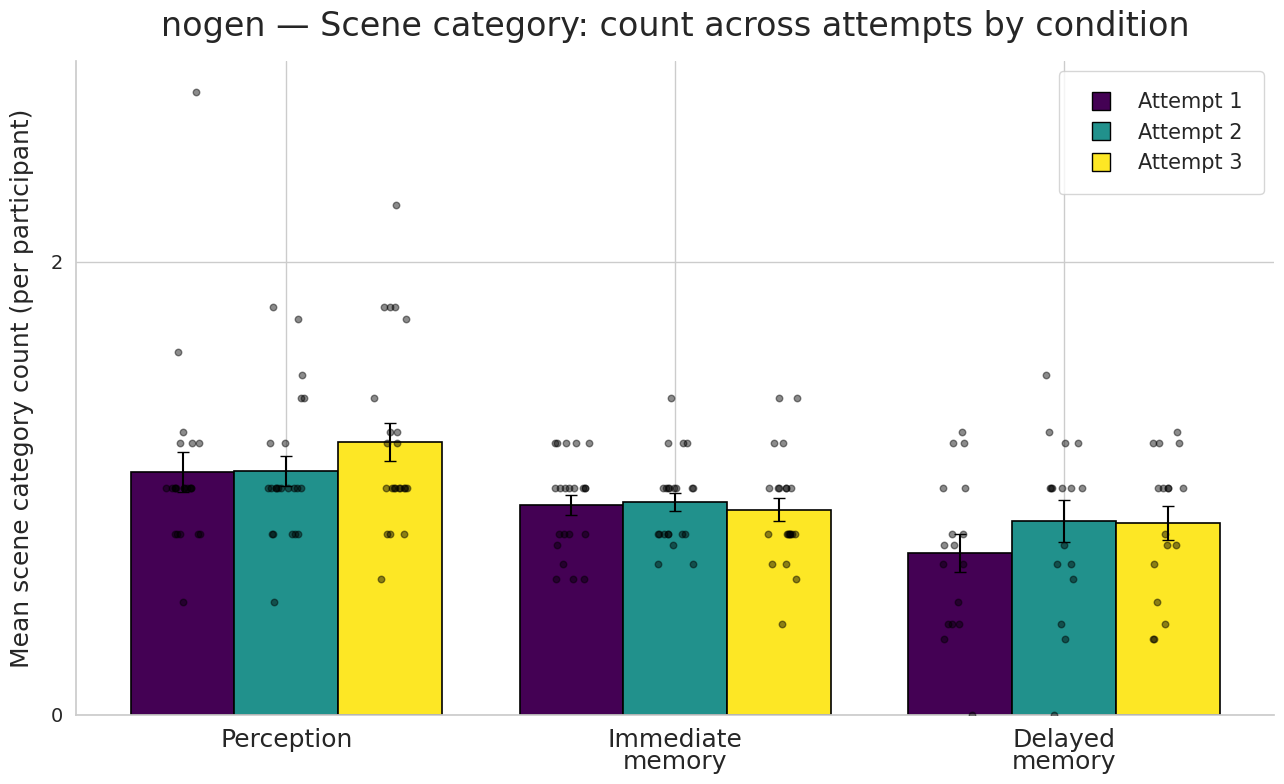

In [18]:
scene_pp = plot_count("scene_category")

## 6. Adjectives

saved: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/nogen/graphs/nlp_graphs/nogen_adjectives_count_by_condition.png


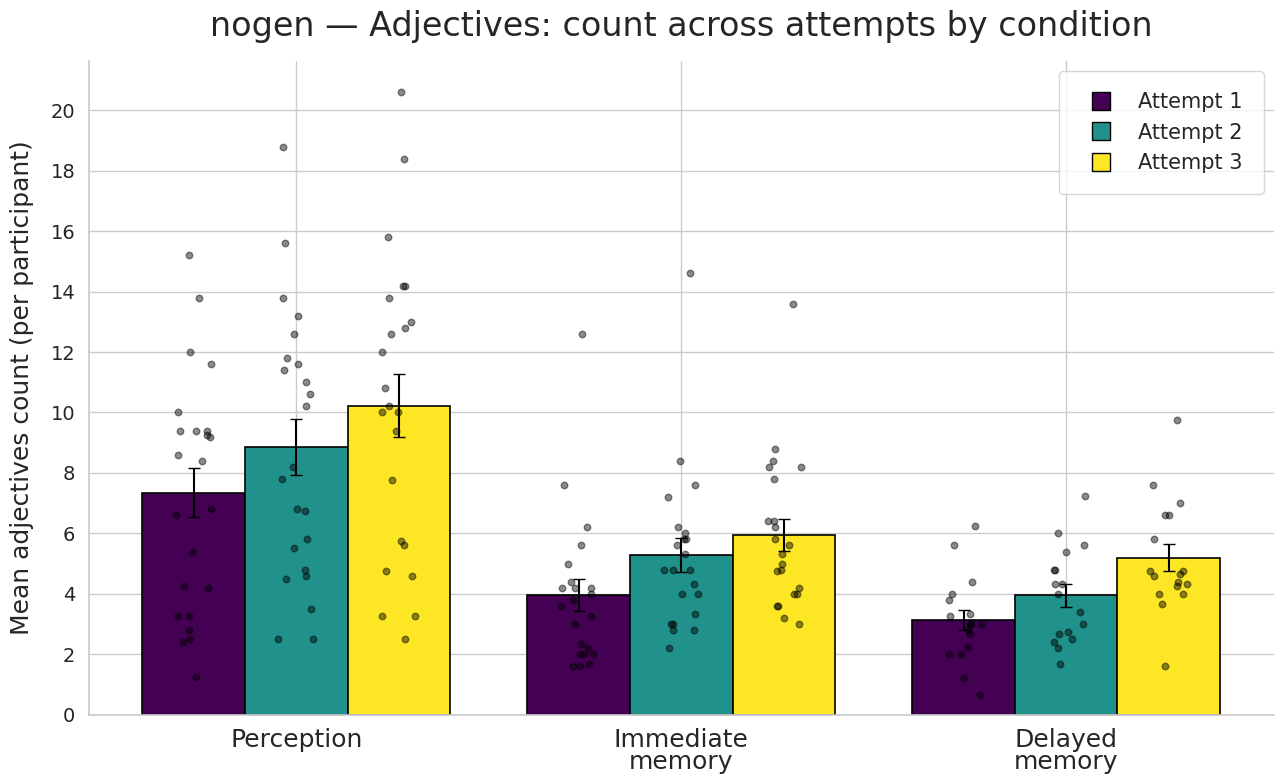

In [19]:
adjectives_pp = plot_count("adjectives")